In [2]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

bq_auth()

project_id = "yhcr-prd-bradfor-bia-core"

# create connection to database
con <- DBI::dbConnect(bigrquery::bigquery(), 
                      project = project_id)

print(paste0("Connected to : ", project_id))

[1] "Connected to : yhcr-prd-bradfor-bia-core"


# Person

In [3]:
person_data = "CB_2489.person_targetage_additionalyears"

person_table <- tbl(con, person_data) |> 
    select(person_id, birth_date, gender_source_value, ethnicity_source_value)


In [4]:
head(person_table)

# Source:   SQL [6 x 4]
# Database: BigQueryConnection
  person_id                birth_date gender_source_value ethnicity_source_value
  <chr>                    <date>     <chr>               <chr>                 
1 EE91E3C77F2B7CB44F1F601… 1998-09-15 M                   Unknown/Refuse to say 
2 C5553DE427E9B8F60E9B5D1… 1998-09-15 M                   Unknown/Refuse to say 
3 AC8CB4071E24E606BFFECC3… 1998-09-15 M                   Unknown/Refuse to say 
4 E4E84D0DEB6692712A8E875… 1998-09-15 M                   Unknown/Refuse to say 
5 64FA4602D88C275E27FDBD1… 1998-09-15 M                   Unknown/Refuse to say 
6 F516562D5CFDDC6CD66FB8E… 1998-09-15 M                   Unknown/Refuse to say 

#### Clean Gender

In [5]:
person_table |> 
  distinct(gender_source_value) |> 
  pull(gender_source_value)

[1] "M"      "F"      NA       "Male"   "I"      "1"      "Female"

In [6]:
person_table <- person_table |> 
  mutate(
    gender_source_value = case_when(
      gender_source_value %in% c("F", "Female", "1") ~ "F",
      gender_source_value %in% c("M", "Male", "2") ~ "M",
      gender_source_value %in% c("N", "I", "U", "", NA) ~ NA_character_,
      TRUE ~ NA_character_  # Handle any other unexpected cases
    )
  )

In [7]:
person_table |> 
  distinct(gender_source_value) |> 
  pull(gender_source_value)

[1] "M" "F" NA

In [8]:
person_table |> 
  filter(is.na(gender_source_value)) |> 
  count()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1     4

#### Clean Ethnicity

In [9]:
person_table |> 
  distinct(ethnicity_source_value) |> 
  pull(ethnicity_source_value)

[1] "Unknown/Refuse to say"                                                                                                                         
 [2] "White:Any other White background"                                                                                                              
 [3] "Asian or Asian British: Bangladeshi - England and Wales ethnic category 2011 census"                                                           
 [4] "Asian or Asian British: Chinese - England and Wales ethnic category 2011 census"                                                               
 [5] "Asian or Asian British: Indian - England and Wales ethnic category 2011 census"                                                                
 [6] "Asian or Asian British: Pakistani - England and Wales ethnic category 2011 census"                                                             
 [7] "Asian or Asian British: any other Asian background - England and Wales ethnic category 2011 census"                                            
 [8] "Black or African or Caribbean or Black British: African - England and Wales ethnic category 2011 census"                                       
 [9] "Black or African or Caribbean or Black British: Caribbean - England and Wales ethnic category 2011 census"                                     
[10] "Black or African or Caribbean or Black British: other Black or African or Caribbean background - England and Wales ethnic category 2011 census"
[11] "Mixed multiple ethnic groups: White and Asian - England and Wales ethnic category 2011 census"                                                 
[12] "Mixed multiple ethnic groups: White and Black African - England and Wales ethnic category 2011 census"                                         
[13] "Mixed multiple ethnic groups: White and Black Caribbean - England and Wales ethnic category 2011 census"                                       
[14] "Mixed multiple ethnic groups: any other Mixed or multiple ethnic background - England and Wales ethnic category 2011 census"                   
[15] "Other ethnic group: Arab - England and Wales ethnic category 2011 census"                                                                      
[16] "Other ethnic group: any other ethnic group - England and Wales ethnic category 2011 census"                                                    
[17] "White: English or Welsh or Scottish or Northern Irish or British - England and Wales ethnic category 2011 census"                              
[18] "White: Gypsy or Irish Traveller - England and Wales ethnic category 2011 census"                                                               
[19] "White: Irish - England and Wales ethnic category 2011 census"

In [10]:
person_table <- person_table |> 
  mutate(
    ethnicity_source_value = sql("REGEXP_REPLACE(ethnicity_source_value, r' - England and Wales ethnic category 2011 census', '')")
  )


In [11]:
person_table |> 
  distinct(ethnicity_source_value) |> 
  pull(ethnicity_source_value)

[1] "Unknown/Refuse to say"                                                                         
 [2] "White:Any other White background"                                                              
 [3] "Asian or Asian British: Bangladeshi"                                                           
 [4] "Asian or Asian British: Chinese"                                                               
 [5] "Asian or Asian British: Indian"                                                                
 [6] "Asian or Asian British: Pakistani"                                                             
 [7] "Asian or Asian British: any other Asian background"                                            
 [8] "Black or African or Caribbean or Black British: African"                                       
 [9] "Black or African or Caribbean or Black British: Caribbean"                                     
[10] "Black or African or Caribbean or Black British: other Black or African or Caribbean background"
[11] "Mixed multiple ethnic groups: White and Asian"                                                 
[12] "Mixed multiple ethnic groups: White and Black African"                                         
[13] "Mixed multiple ethnic groups: White and Black Caribbean"                                       
[14] "Mixed multiple ethnic groups: any other Mixed or multiple ethnic background"                   
[15] "Other ethnic group: Arab"                                                                      
[16] "Other ethnic group: any other ethnic group"                                                    
[17] "White: English or Welsh or Scottish or Northern Irish or British"                              
[18] "White: Gypsy or Irish Traveller"                                                               
[19] "White: Irish"

In [12]:
person_table <- person_table |>     
    mutate(ethnicity = case_when(
        str_detect(ethnicity_source_value, "Unknown") ~ NA_character_,
        str_detect(ethnicity_source_value, "Asian or Asian British: Indian") ~ "South Asian",
        str_detect(ethnicity_source_value, "Asian or Asian British: Pakistani") ~ "South Asian",
        str_detect(ethnicity_source_value, "Asian or Asian British: Bangladeshi") ~ "South Asian",
        str_detect(ethnicity_source_value, "White: English or Welsh or Scottish or Northern Irish or British") ~ "White British",
        str_detect(ethnicity_source_value, "White: Gypsy or Irish Traveller") ~ "Gypsy or Irish Traveller",
        TRUE ~ "Other"
    ))

In [13]:
person_table |> 
  distinct(ethnicity) |> 
  pull(ethnicity)

[1] NA                         "Other"                   
[3] "South Asian"              "White British"           
[5] "Gypsy or Irish Traveller"

In [14]:
person_table |> 
  filter(is.na(ethnicity)) |> 
  count()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1  6425

In [15]:
person_table <- person_table |>
    rename(gender = gender_source_value) |>
    select(-ethnicity_source_value)

person_table

# Source:   SQL [?? x 4]
# Database: BigQueryConnection
   person_id                                         birth_date gender ethnicity
   <chr>                                             <date>     <chr>  <chr>    
 1 EE91E3C77F2B7CB44F1F601317E2DE5EE76ABB0941F24D47… 1998-09-15 M      NA       
 2 C5553DE427E9B8F60E9B5D1E83391E1B660F415A3924B630… 1998-09-15 M      NA       
 3 AC8CB4071E24E606BFFECC380A9EA11546158370916C4D8D… 1998-09-15 M      NA       
 4 E4E84D0DEB6692712A8E875B701E097EB61235069C566269… 1998-09-15 M      NA       
 5 64FA4602D88C275E27FDBD17EA4678E378D7B297D91C2CDB… 1998-09-15 M      NA       
 6 F516562D5CFDDC6CD66FB8EA18399D11BB0E2E042F569D91… 1998-09-15 M      NA       
 7 489C7B994FF3B53233C59C6F1E27AC82DD5113A73916F113… 1998-09-15 M      NA       
 8 307670F8DEB9740E1DA1B891C7B94B4CD5E92F3CE5074DFF… 1998-09-15 M      NA       
 9 61ED6B44E834F571E87692AB7C7A407D87FE9B459920BD63… 1998-09-15 M      NA       
10 A408559943EC1619A8A389831E1E0324A264F76DCFD3AE42… 

In [16]:
person_table |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      23385

In [17]:
person_table |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 24429

In [18]:
distinct_person_table <- person_table |>
    distinct()

In [19]:
distinct_person_table |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 23385

#### Get more ethnicity data

In [20]:
school_census_data = "CB_2489.cb_StudentAdditionalInfoFromCensus"

In [21]:
school_census_table <- tbl(con, school_census_data) |>
    select(person_id, Ethnicity)

In [22]:
head(school_census_table)

# Source:   SQL [6 x 2]
# Database: BigQueryConnection
  person_id                                                        Ethnicity
  <chr>                                                            <chr>    
1 4A2AD68DFB6F3E01578C742C05A033F477237CC24FE0C7F1B64DA5E58EB83BD9 MOTH     
2 0A9D44CD352FE47273953BD7AB1FA9E4335B565FDFA69B045D9506F3829463C0 BOTB     
3 41D31CEA128C214AD816B1FE3D46C7A78A5DEC9CEF55453C96CF07AE16F3A5F4 WEEU     
4 21FD3187568CC045195329EADD277AE441E63BD8BC97F115AAF7E985DF983068 OKRD     
5 83F6D7C1D1A9FEEFCA1F5C2DD380FAD3BFA21B2FCE7FA7639494ECE79D2CB0A7 WEEU     
6 9F5D0A6E879AB05C11177B3AA26EBB3FE11E7F7FA0A8A2BA094E813E2874BD46 CHNE     

In [23]:
school_census_table |> 
  filter(is.na(Ethnicity)) |> 
  count()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
        n
    <int>
1 3105654

In [24]:
school_census_table <- school_census_table |>
    filter(!is.na(Ethnicity))

In [25]:
school_census_table |> 
  distinct(Ethnicity) |> 
  pull(Ethnicity)

[1] "WALB" "OARA" "MWAO" "AKPA" "WOWB" "MWOE" "MCOE" "BSUD" "BOTB" "COCH"
 [11] "BCON" "WPOR" "ASLT" "WGRK" "WGRC" "OMAL" "OTHA" "AIND" "AMPK" "APKN"
 [21] "BNAM" "WEEU" "WSCO" "MWAP" "MWBA" "BAOF" "WTUK" "OFIL" "WWEU" "WCOR"
 [31] "ASRO" "WROR" "AKAO" "OIRN" "WTUR" "CHKC" "WSER" "WCRO" "MWBC" "WOTH"
 [41] "WTUC" "CMAL" "WGRE" "WROM" "OAFG" "BSOM" "BAFR" "MBOE" "REFU" "CHNE"
 [51] "WROG" "OLIB" "MWAI" "WIRI" "MWCH" "WIRT" "MABL" "ANEP" "ASNL" "OLAM"
 [61] "WKOS" "OKOR" "OLEB" "OJPN" "OOEG" "NOBT" "BCRB" "BOTH" "MOTH" "BNGN"
 [71] "BGHA" "MAOE" "MOTM" "WITA" "AAFR" "OIRQ" "OMRC" "BANN" "OPOL" "MACH"
 [81] "OEGY" "OVIE" "WBOS" "AOTH" "MWAS" "OOTH" "WOTW" "WEUR" "AOTA" "OKRD"
 [91] "OYEM" "WROO" "BEUR" "WWEL" "BSLN" "ABAN" "AOPK" "WBRI" "WENG" "11  "

In [26]:
school_census_table <- school_census_table |> 
  mutate(
    Ethnicity = case_when(
      Ethnicity %in% c("ABAN", "AIND", "AKAO", "AKPA", "AMPK", "AOPK", "APKN") ~ "South Asian",
      Ethnicity %in% c("WBRI", "WENG", "WCOR", "WSCO", "WOWB", "WWEL", "WIRI") ~ "White British",
        Ethnicity %in% c("WROG", "WROM", "WROO") ~ "Gypsy or Irish Traveller",
      Ethnicity %in% c("NOBT", "UNCL", "REFU", "", NA) ~ NA_character_,
      TRUE ~ "Other"  # Handle any other unexpected cases
    )
  ) 

In [27]:
school_census_table |> 
  distinct(Ethnicity) |> 
  pull(Ethnicity)

[1] "White British"            "Other"                   
[3] "Gypsy or Irish Traveller" "South Asian"             
[5] NA

In [28]:
head(school_census_table)

# Source:   SQL [6 x 2]
# Database: BigQueryConnection
  person_id                                                        Ethnicity
  <chr>                                                            <chr>    
1 2C2ACF8DF049F9099B4B64781B3925AF10302FBA0BABB5A69B4C05EAA06EDF91 Other    
2 91E0083AFC7FF47A39987EE5806369C563E4DC1D46769E4F9EE3D45F8FBC4F4B Other    
3 777105A1F6692B9760AF1DCBE42999B1C0AFF26FDFE1E0829A6748FFA77249F9 Other    
4 19DFE3DF5202390B2C95FCD78C2E3818A3F3C22442CFBF89B8DF85E4EA156480 Other    
5 2CDAEE9B60AE5D979AF574E621397B8272154F1EE8D37917653539E4A44F86FB Other    
6 ADDD983979FB7E8833C5CBE964B604ADDED050A2033E65AE384D1941F98E7F3A Other    

In [29]:
school_census_table |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1     300615

In [30]:
school_census_table |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
        n
    <int>
1 3709036

In [31]:
school_census_table_filtered <- school_census_table %>%
  semi_join(distinct_person_table, by = "person_id")

In [32]:
school_census_table_filtered |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      19327

In [33]:
school_census_table_filtered |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
       n
   <int>
1 370747

In [34]:
school_census_table_filtered <- school_census_table_filtered |> 
  distinct(person_id, .keep_all = TRUE)

In [35]:
combined_ethnicity <- distinct_person_table |> 
    rename(person_ethnicity = ethnicity) |> 
    left_join(school_census_table_filtered, by = join_by(person_id)) |> 
    mutate(CombinedEthnicity = coalesce(person_ethnicity, Ethnicity))

In [36]:
head(combined_ethnicity)

# Source:   SQL [6 x 6]
# Database: BigQueryConnection
  person_id       birth_date gender person_ethnicity Ethnicity CombinedEthnicity
  <chr>           <date>     <chr>  <chr>            <chr>     <chr>            
1 EE91E3C77F2B7C… 1998-09-15 M      NA               South As… South Asian      
2 C5553DE427E9B8… 1998-09-15 M      NA               White Br… White British    
3 AC8CB4071E24E6… 1998-09-15 M      NA               White Br… White British    
4 E4E84D0DEB6692… 1998-09-15 M      NA               South As… South Asian      
5 64FA4602D88C27… 1998-09-15 M      NA               White Br… White British    
6 F516562D5CFDDC… 1998-09-15 M      NA               White Br… White British    

In [37]:
combined_ethnicity |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      23385

In [38]:
combined_ethnicity |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 23385

In [39]:
data <- combined_ethnicity |> 
    select(person_id, birth_date, gender, CombinedEthnicity)

data

# Source:   SQL [?? x 4]
# Database: BigQueryConnection
   person_id                                 birth_date gender CombinedEthnicity
   <chr>                                     <date>     <chr>  <chr>            
 1 EE91E3C77F2B7CB44F1F601317E2DE5EE76ABB09… 1998-09-15 M      South Asian      
 2 C5553DE427E9B8F60E9B5D1E83391E1B660F415A… 1998-09-15 M      White British    
 3 AC8CB4071E24E606BFFECC380A9EA11546158370… 1998-09-15 M      White British    
 4 E4E84D0DEB6692712A8E875B701E097EB6123506… 1998-09-15 M      South Asian      
 5 64FA4602D88C275E27FDBD17EA4678E378D7B297… 1998-09-15 M      White British    
 6 F516562D5CFDDC6CD66FB8EA18399D11BB0E2E04… 1998-09-15 M      White British    
 7 489C7B994FF3B53233C59C6F1E27AC82DD5113A7… 1998-09-15 M      White British    
 8 307670F8DEB9740E1DA1B891C7B94B4CD5E92F3C… 1998-09-15 M      White British    
 9 61ED6B44E834F571E87692AB7C7A407D87FE9B45… 1998-09-15 M      White British    
10 A408559943EC1619A8A389831E1E0324A264F76D… 1998-09-

In [40]:
data |>
    summarise(num_unique = n_distinct(person_id))

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
  num_unique
       <int>
1      23385

In [41]:
data |>
    tally()

# Source:   SQL [1 x 1]
# Database: BigQueryConnection
      n
  <int>
1 23385

In [42]:
data_df <- data |>
    collect()

In [43]:
data_df

person_id,birth_date,gender,CombinedEthnicity
<chr>,<date>,<chr>,<chr>
EE91E3C77F2B7CB44F1F601317E2DE5EE76ABB0941F24D4714026B3E30FC313C,1998-09-15,M,South Asian
C5553DE427E9B8F60E9B5D1E83391E1B660F415A3924B630742D52A0517F5219,1998-09-15,M,White British
AC8CB4071E24E606BFFECC380A9EA11546158370916C4D8D954FA76D63FA81AE,1998-09-15,M,White British
E4E84D0DEB6692712A8E875B701E097EB61235069C56626900C0951E9B112B6D,1998-09-15,M,South Asian
64FA4602D88C275E27FDBD17EA4678E378D7B297D91C2CDB914150ED0CBF3785,1998-09-15,M,White British
F516562D5CFDDC6CD66FB8EA18399D11BB0E2E042F569D918285FF96C3377338,1998-09-15,M,White British
489C7B994FF3B53233C59C6F1E27AC82DD5113A73916F113EE95ACCF58DB792D,1998-09-15,M,White British
307670F8DEB9740E1DA1B891C7B94B4CD5E92F3CE5074DFF0E3743C22A1084D5,1998-09-15,M,White British
61ED6B44E834F571E87692AB7C7A407D87FE9B459920BD63240D425C1984CA73,1998-09-15,M,White British


In [47]:
data_df |>
    summarise(num_unique = n_distinct(person_id))

num_unique
<int>
23385


In [48]:
data_df <- data_df |>
    mutate(cohort = ifelse(as.Date(birth_date) < as.Date("1999-09-01"), '2000/01', '2001/02'))
            
        

In [49]:
data_df

person_id,birth_date,gender,CombinedEthnicity,cohort
<chr>,<date>,<chr>,<chr>,<chr>
EE91E3C77F2B7CB44F1F601317E2DE5EE76ABB0941F24D4714026B3E30FC313C,1998-09-15,M,South Asian,2000/01
C5553DE427E9B8F60E9B5D1E83391E1B660F415A3924B630742D52A0517F5219,1998-09-15,M,White British,2000/01
AC8CB4071E24E606BFFECC380A9EA11546158370916C4D8D954FA76D63FA81AE,1998-09-15,M,White British,2000/01
E4E84D0DEB6692712A8E875B701E097EB61235069C56626900C0951E9B112B6D,1998-09-15,M,South Asian,2000/01
64FA4602D88C275E27FDBD17EA4678E378D7B297D91C2CDB914150ED0CBF3785,1998-09-15,M,White British,2000/01
F516562D5CFDDC6CD66FB8EA18399D11BB0E2E042F569D918285FF96C3377338,1998-09-15,M,White British,2000/01
489C7B994FF3B53233C59C6F1E27AC82DD5113A73916F113EE95ACCF58DB792D,1998-09-15,M,White British,2000/01
307670F8DEB9740E1DA1B891C7B94B4CD5E92F3CE5074DFF0E3743C22A1084D5,1998-09-15,M,White British,2000/01
61ED6B44E834F571E87692AB7C7A407D87FE9B459920BD63240D425C1984CA73,1998-09-15,M,White British,2000/01


In [50]:
data_df |>
    filter(person_id == 'EE7845EC75B224F12468CE881715440AC1910374E35002803A04E7FBEA4274D8')

person_id,birth_date,gender,CombinedEthnicity,cohort
<chr>,<date>,<chr>,<chr>,<chr>


#### save person cohorts as csv

In [51]:
write.csv(data_df, "data/Roma_Ethnicity_cohort2.csv", row.names = FALSE)

In [128]:
write.csv(data_df, "data/additional_person_cohorts.csv", row.names = FALSE)

In [20]:
data_df = read.csv("data/additional_person_cohorts.csv", header = TRUE)

# Destinations

In [52]:
dest_data = "CB_2489.cb_NCCIS_2011_to_2019"

dest_table <- tbl(con, dest_data) |>
    select(person_id, NCCIS_ACADYR, NCCIS_MonthNo, NCCIS_Current_Activity_Code) |> 
    # convert to df
    collect()


Auto-refreshing stale OAuth token.



In [3]:
head(dest_table)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code
<chr>,<chr>,<dbl>,<chr>
A13A4AB803D142E005B9F053ED203A10F495B41533B71DADD926AAED8B785635,2010/2011,9,820
353D10685A9B1403166AF094E3F242AE54F4156FC5EF10D668D8DB5AF1DFCF42,2010/2011,9,820
3E85A9DD8DB55EE96F8F76F9C5225FA848D724D1A255021B7EFB056E5072DF23,2010/2011,9,330
51C7DC9436F840B036B53A56C846A2209CD700FCA83CC57A276B76E0B0415AA8,2010/2011,9,340
E6F357897ECA006D603DAD16BB8E7B8A6889A8BBCD7ACA8B5978C9A4273B8B4D,2010/2011,9,330
E6F357897ECA006D603DAD16BB8E7B8A6889A8BBCD7ACA8B5978C9A4273B8B4D,2010/2011,9,330


In [4]:
unique(dest_table$NCCIS_ACADYR)

[1] "2010/2011" "2011/2012" "2012/2013" "2013/2014" "2014/2015" "2015/2016"
[7] "2017/2018" "2016/2017" "2018/2019"

In [5]:
dest_targetyears_A <- dest_table |>
    filter(NCCIS_ACADYR %in% c('2015/2016','2016/2017'))

In [6]:
summary(dest_targetyears_A)

  person_id         NCCIS_ACADYR       NCCIS_MonthNo   
 Length:609231      Length:609231      Min.   : 1.000  
 Class :character   Class :character   1st Qu.: 3.000  
 Mode  :character   Mode  :character   Median : 7.000  
                                       Mean   : 6.556  
                                       3rd Qu.:10.000  
                                       Max.   :12.000  
 NCCIS_Current_Activity_Code
 Length:609231              
 Class :character           
 Mode  :character           
                            
                            
                            

In [7]:
dest_data_17_21 = "CB_2489.cb_NCCIS_2017_to_2021"

dest_table_17_21 <- tbl(con, dest_data_17_21) |>
    select(person_id, NCCIS_ACADYR, NCCIS_MonthNo, NCCIS_Current_Activity_Code) |> 
    # convert to df
    collect()


In [8]:
head(dest_table_17_21)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code
<chr>,<chr>,<dbl>,<chr>
85BF99E71C509B9181CA1053E45AF4D995F246137B0428C737F288628B43C405,2016/2017,9,810
B1A0235987DE03024669795747D96B09131E6AC9D06812D5BF0E0B34B0A8CF2C,2016/2017,9,310
E84670E8D111E1C2AE0827CEF99A7016B9186A847ADD58BC397BCA590D27C783,2016/2017,9,310
65D2CB7017EB2AD41E41018D00A3A8A347E9029D6196AAD114E6973E0D71A988,2016/2017,9,320
NA,2016/2017,9,310
39AB36E6210AA8C39E524DF7E19EFBB888FBA533E66632C9170A0B0488D180FB,2016/2017,9,820


In [9]:
dest_table_17_21 <- dest_table_17_21 |>
    filter(!is.na(person_id))

In [10]:
unique(dest_table_17_21$NCCIS_ACADYR)

[1] "2016/2017" "2017/2018" "2018/2019" "2019/2020" "2020/2021"

In [11]:
dest_targetyears_B <- dest_table_17_21 |>
    filter(NCCIS_ACADYR %in% c('2016/2017'))

In [12]:
summary(dest_targetyears_B)

  person_id         NCCIS_ACADYR       NCCIS_MonthNo   
 Length:228885      Length:228885      Min.   : 1.000  
 Class :character   Class :character   1st Qu.: 3.000  
 Mode  :character   Mode  :character   Median : 6.000  
                                       Mean   : 6.495  
                                       3rd Qu.: 9.000  
                                       Max.   :12.000  
 NCCIS_Current_Activity_Code
 Length:228885              
 Class :character           
 Mode  :character           
                            
                            
                            

#### Compare dataframes for the same years but different data tables

In [13]:
diff1 <- anti_join(dest_targetyears_A, dest_targetyears_B)  # Rows in A but not in B
diff2 <- anti_join(dest_targetyears_B, dest_targetyears_A)  # Rows in B but not in A

Joining with `by = join_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo,
NCCIS_Current_Activity_Code)`
Joining with `by = join_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo,
NCCIS_Current_Activity_Code)`


In [14]:
diff1

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code
<chr>,<chr>,<dbl>,<chr>
76AB1597F247875C772B47CBC2323BE0AE3F2A5C3A63E4D28D62CFD70696EAA1,2015/2016,9,630
ACA7E9057E7FADC3EAC55E89E2AE1419B4CE0358B881D2DAD3B6D76A98F9CA12,2015/2016,9,320
AE7D8834D70BEBABE0F7BE153397464C287D7B5B3F97C7DB7FC3BF81F67DAF5F,2015/2016,9,320
FFF7BFBE8E8B2559A255B9ACC2AB0F2D14CD3772893E151864C83400BDF4CA58,2015/2016,9,320
438DEA947795AA9F3C0129C44D72F8643157BCC9C229CC114448FB31E7085C5F,2015/2016,9,310
C4723F5639A2A072DA2342222EBBE61043C452E127F5D5C18528A4F91A93C501,2015/2016,9,240
BE25F44BCFBD47EEEC26240ECE2A12A7C5768592B7591F4B790F1AFBD7FD5560,2015/2016,9,320
6EDB09623439EB620DE97B01389534D508FF2C37EEE681CE279826FB8ED336E5,2015/2016,9,320
C7BA4C949FA8AF0EABA582FDFFA339173209CFB81A902BBFECA74A756BB39A42,2015/2016,9,810


In [15]:
diff2

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code
<chr>,<chr>,<dbl>,<chr>
10053CC8143D0BC3A52B117B144884274ECE37CCE9C57F4E8171C156D57CAF8F,2016/2017,9,310
BA928A19EE20B29FF261CDAF5A09A17C34C0365FE76BC2D00B498487A6C6E5FA,2016/2017,9,320
B4A629E764E85F54DB8E64DB494D7A5FB2B20745808823E1D67EB567ED21811C,2016/2017,9,820
1F3F2A6A3F4885C0C1596E6A5613C2BD549C0527AF4A822136637DD352665045,2016/2017,9,810
7FEDAB715DAACBBA18F770878A8752D2A07EB793719C1AA3E1535B07C22B130D,2016/2017,9,430
1BFF9F036C8DD0C66E5330B88F6B5A2A7A7105809E2A94BFD6AF7B3A81F60399,2016/2017,9,710
E143A22ECB1217DD92427235BEC5AA7A2E94741F3A8AE7AE813CC50D08B59706,2016/2017,9,810
C885B2B1FD41FF3EE83E36A94414834DEDF140A0AC0C592765D903D63669287D,2016/2017,9,810
5743F2BB523AE8E2B6180F964A01A26D8E21D31F971F335B9BEF9C3017197EDA,2016/2017,9,810


#### Merge two dfs for destinations, avoiding duplicates where rows appear in both

In [16]:
destinations <- bind_rows(dest_targetyears_A, dest_targetyears_B) |> 
  distinct()

In [17]:
head(destinations)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code
<chr>,<chr>,<dbl>,<chr>
76AB1597F247875C772B47CBC2323BE0AE3F2A5C3A63E4D28D62CFD70696EAA1,2015/2016,9,630
ACA7E9057E7FADC3EAC55E89E2AE1419B4CE0358B881D2DAD3B6D76A98F9CA12,2015/2016,9,320
AE7D8834D70BEBABE0F7BE153397464C287D7B5B3F97C7DB7FC3BF81F67DAF5F,2015/2016,9,320
FFF7BFBE8E8B2559A255B9ACC2AB0F2D14CD3772893E151864C83400BDF4CA58,2015/2016,9,320
438DEA947795AA9F3C0129C44D72F8643157BCC9C229CC114448FB31E7085C5F,2015/2016,9,310
C4723F5639A2A072DA2342222EBBE61043C452E127F5D5C18528A4F91A93C501,2015/2016,9,240


In [18]:
destinations |> 
  summarise(num_unique = n_distinct(person_id))

num_unique
<int>
44621


## Filter destinations to target cohort

In [21]:
destinations_filtered <- destinations |>
    semi_join(data_df, by = "person_id") |>
    left_join(data_df |> select(person_id, cohort), by = "person_id")

In [22]:
destinations_filtered <- destinations_filtered |>
  filter(!(cohort == '1998/99' & NCCIS_ACADYR == '2016/2017')) |>
  filter(!(cohort == '1999/00' & NCCIS_ACADYR == '2015/2016'))

In [23]:
destinations_filtered

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>
42274E959CD577FFC08AF6C01D2E584755BE6176D7AAAB2852CEB554DA72C694,2015/2016,9,650,1998/99
F1BE95953E6974F219D6F3E7236FDF8572F5710436AE4DBD689FB7FA448B08E1,2015/2016,9,310,1998/99
F85EF3297BE0264C33692EF3A12E8D3588AD91AF392E3AC8AC66DA88A21C248D,2015/2016,9,616,1998/99
093F44F9B644EAF860C57CD47E3E8720B68C19D6C1AF8F0D28D321116E25423F,2015/2016,9,810,1998/99
4E073ACBD04491273DA9DBF28F9BA45BD228579F64960D9ACAD809CFAC129C82,2015/2016,9,810,1998/99
0893D24C1FBCE03BBD33127781149AB6B90EFF9363E816DD03F7F8257C735BFA,2015/2016,9,320,1998/99
031012929FCDEA52AC7756B03B77B7DA5C1F006A5F4D5061642F3600BC1B9E48,2015/2016,9,340,1998/99
0E75619B7505B0650BF24F0A5A80E6C39026195248A62413AA1CE5BF1EF6DC25,2015/2016,9,619,1998/99
B1C6E7998CA619D6563716893115EE63DF0A89510B7C9F46F3E4CC0FAC65209C,2016/2017,9,410,1999/00


In [24]:
destinations_filtered |>
    summarise(num_unique = n_distinct(person_id))

num_unique
<int>
17742


## Explore NEET destinations

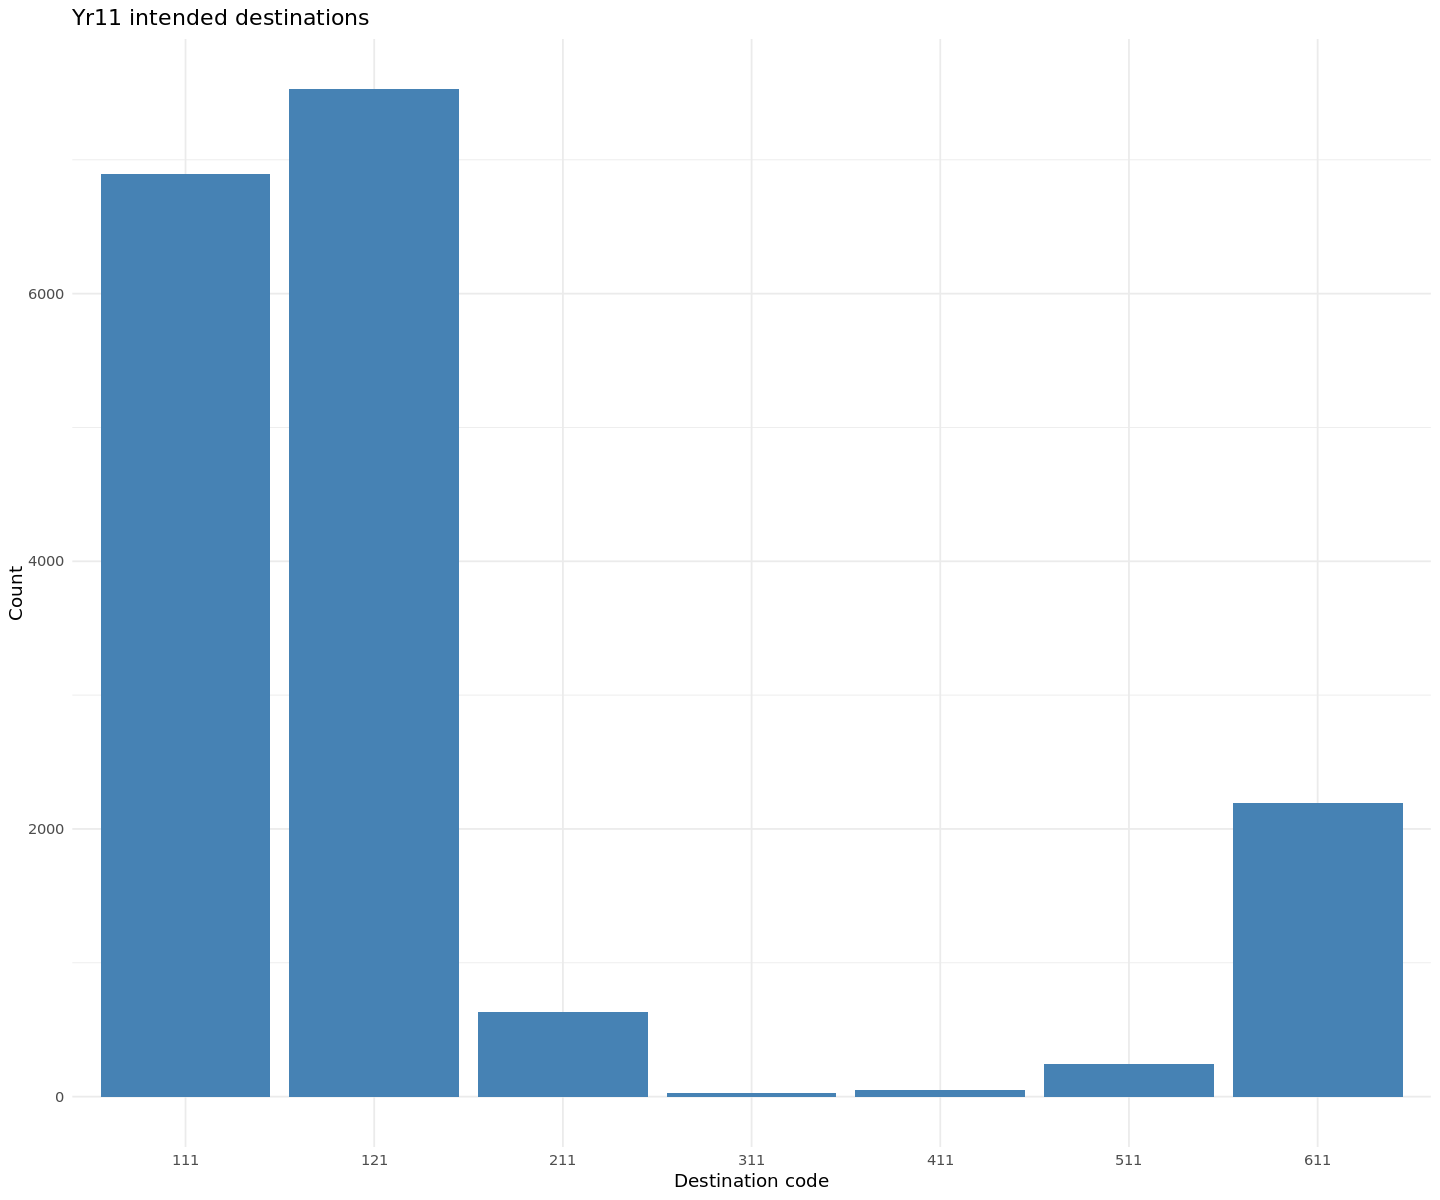

In [68]:
options(repr.plot.width = 12, repr.plot.height = 10)

ggplot(filter(destinations_filtered, !is.na(NCCIS_Year_11_Intended_Destination)), aes(x = NCCIS_Year_11_Intended_Destination)) +
      geom_bar(fill = "steelblue") +
      labs(title = "Yr11 intended destinations", x = "Destination code", y = "Count") +
      theme_minimal()

In [69]:
NEET_dest <- destinations_filtered |>
    filter(NCCIS_Year_11_Intended_Destination %in% c('411','511','611'))

In [70]:
NEET_dest |>
 group_by(cohort) |>
 tally()

cohort,n
<chr>,<int>
2000/01,1130
2001/02,1352


In [71]:
NEET_dest |> 
  group_by(cohort) |>
  summarise(num_unique = n_distinct(person_id))

cohort,num_unique
<chr>,<int>
2000/01,125
2001/02,134


In [72]:
NEET_dest |> 
  filter(person_id == '5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,12,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,8,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,2,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,6,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,10,511,810,2018-09-01,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,11,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,5,511,210,2018-09-05,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,9,511,810,2018-09-01,NA,815,2001/02
5C2105DDD9AB87620BB209C1D3EB10D0B62025614D92DA07BA4F229BC254D273,2018/2019,4,511,210,2018-09-05,NA,815,2001/02


In [73]:
NEET_dest |> 
  filter(person_id == '26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,2,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,9,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,12,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,10,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,4,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,5,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,8,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,11,411,320,2018-09-05,NA,811,2001/02
26EC80FD819A62ED03E3A9B47BB5F3F72807675A7B8079A1A392629CBD033260,2018/2019,1,411,320,2018-09-05,NA,811,2001/02


In [74]:
NEET_dest |> 
  filter(NCCIS_Year_11_Intended_Destination == '611')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A99B5F4C5D1A34FCA24B8C63A1F4CD08D479A13C6A3A443C0A78DC96F45B90D5,2017/2018,2,611,330,2017-08-21,NA,878,2000/01
59D31DC292BEDB99D598A00CE71257F4733F65F1C13596FA06B1989DC5F4E413,2017/2018,9,611,619,2017-09-01,2017-09-01,874,2000/01
494096F9B10CB17E72C3C9EB0696CFE8871F82A6FB59F6833A794E52575DDCF7,2018/2019,4,611,619,2018-09-01,2018-09-01,925,2001/02
83D83391B672E60C65E04FD43BAB01BA4D09EF35CC4A241A0463386F93149577,2018/2019,7,611,230,2018-09-03,NA,801,2001/02
E4ED8FB27BC71E66878E74329267C3C2F0939A0A9C1EC7BFD98628DA395BAADF,2018/2019,10,611,230,2018-09-01,NA,925,2001/02
082D44F8712320F25C3C2EA194BF8E20343D6551A45D05E14A457CE81870D1B1,2018/2019,11,611,220,2018-09-04,NA,812,2001/02
DBC7D6FBB4AF37D464372DA31B732C2FAC7407ED81E18D8146A77306F05AD756,2018/2019,1,611,210,2018-09-05,NA,815,2001/02
0A7B9B6B2AAE5FA68EF0C0F1C98B4C61B6F9A98775E044B0B77C977498EB046C,2018/2019,8,611,230,2018-09-05,NA,815,2001/02
06490B3EC6B7808C3962B2944C36EA3F223D1229B9B35465B49E55DB0B5B011A,2017/2018,1,611,270,2017-09-04,NA,815,2000/01


## Explore NEET activity

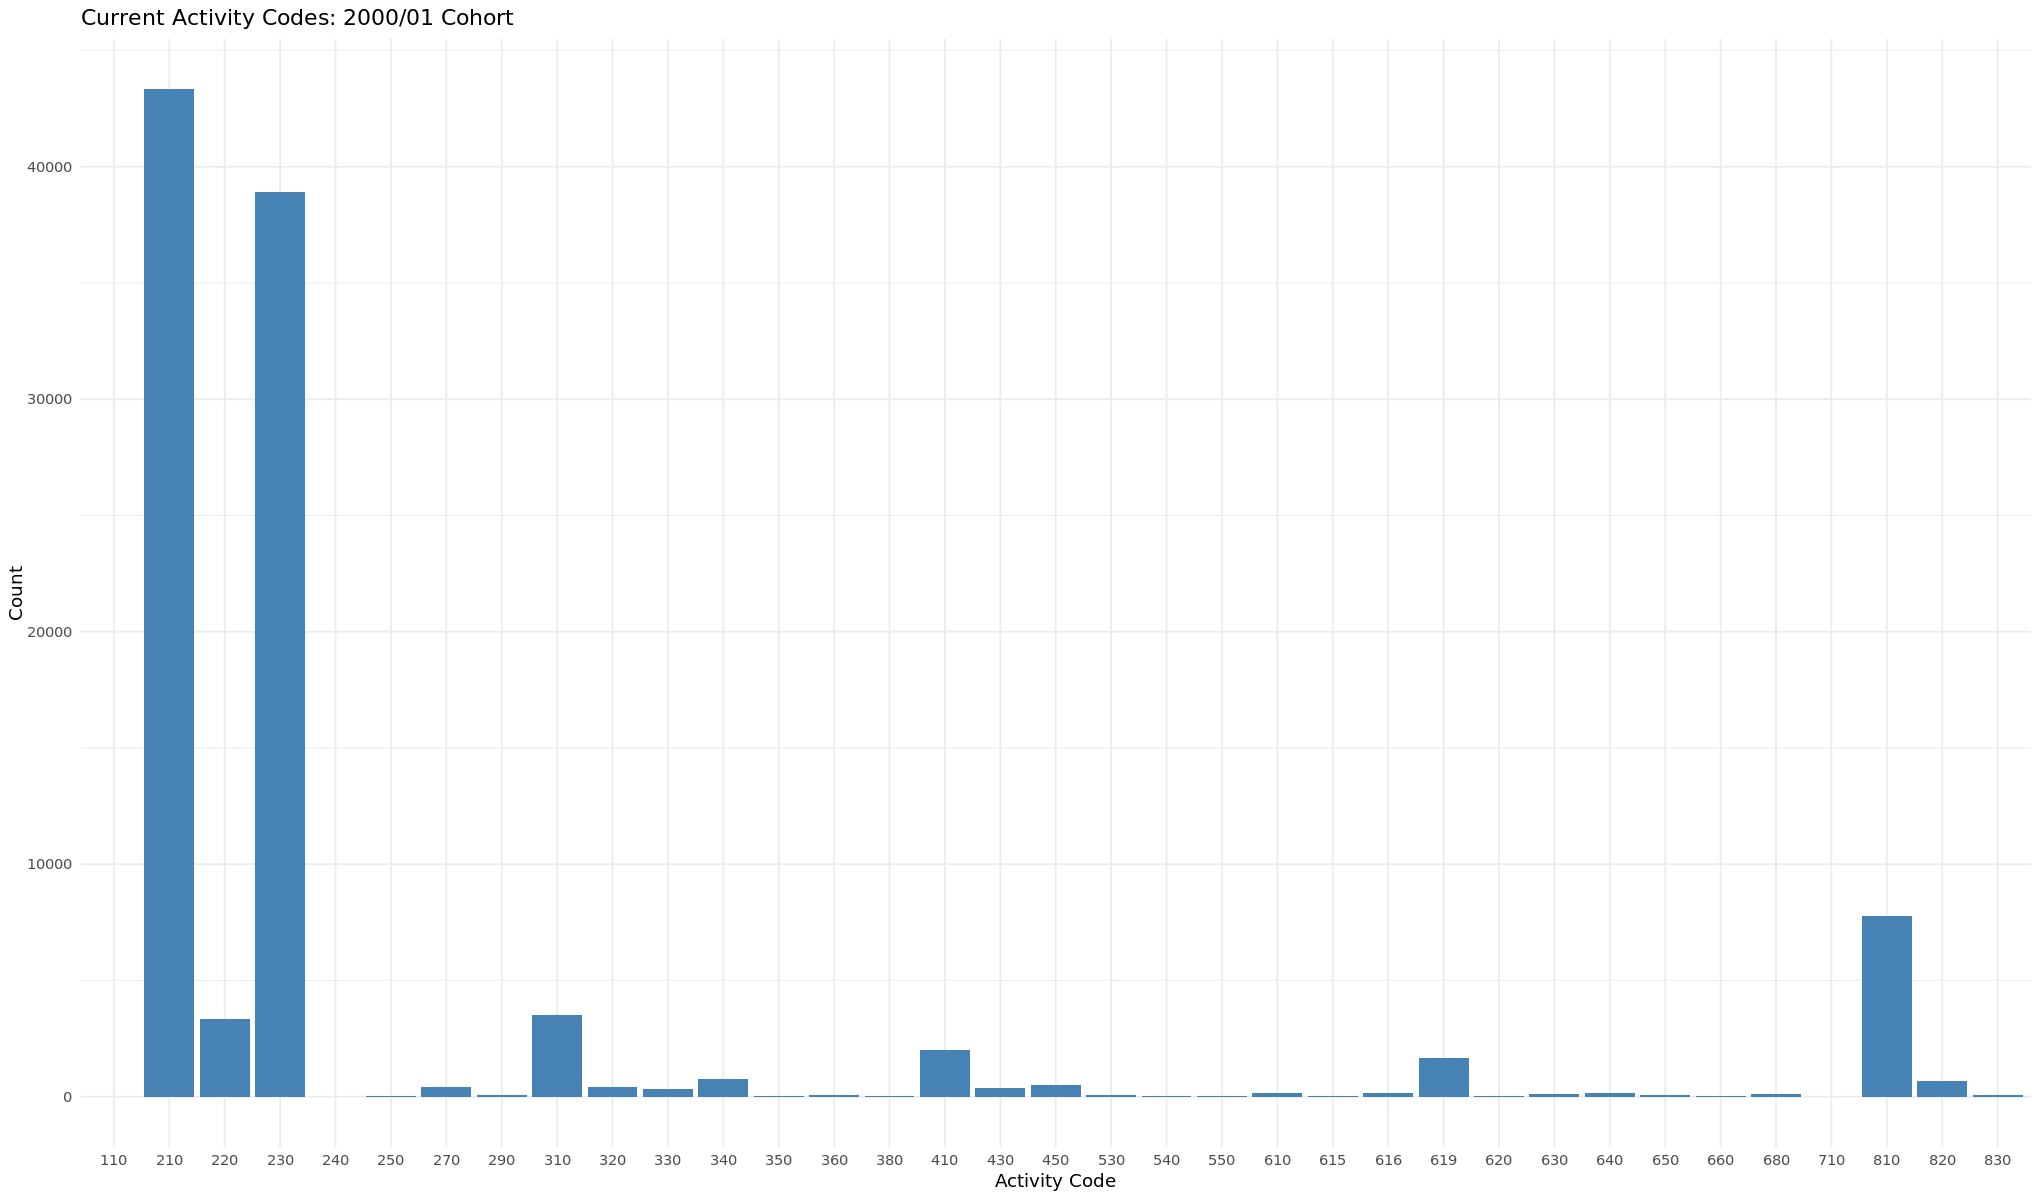

In [75]:
options(repr.plot.width = 17, repr.plot.height = 10)

destinations_filtered %>%
  filter(cohort == '2000/01') %>%
  ggplot(aes(x = NCCIS_Current_Activity_Code)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Current Activity Codes: 2000/01 Cohort", x = "Activity Code", y = "Count") +
  theme_minimal()

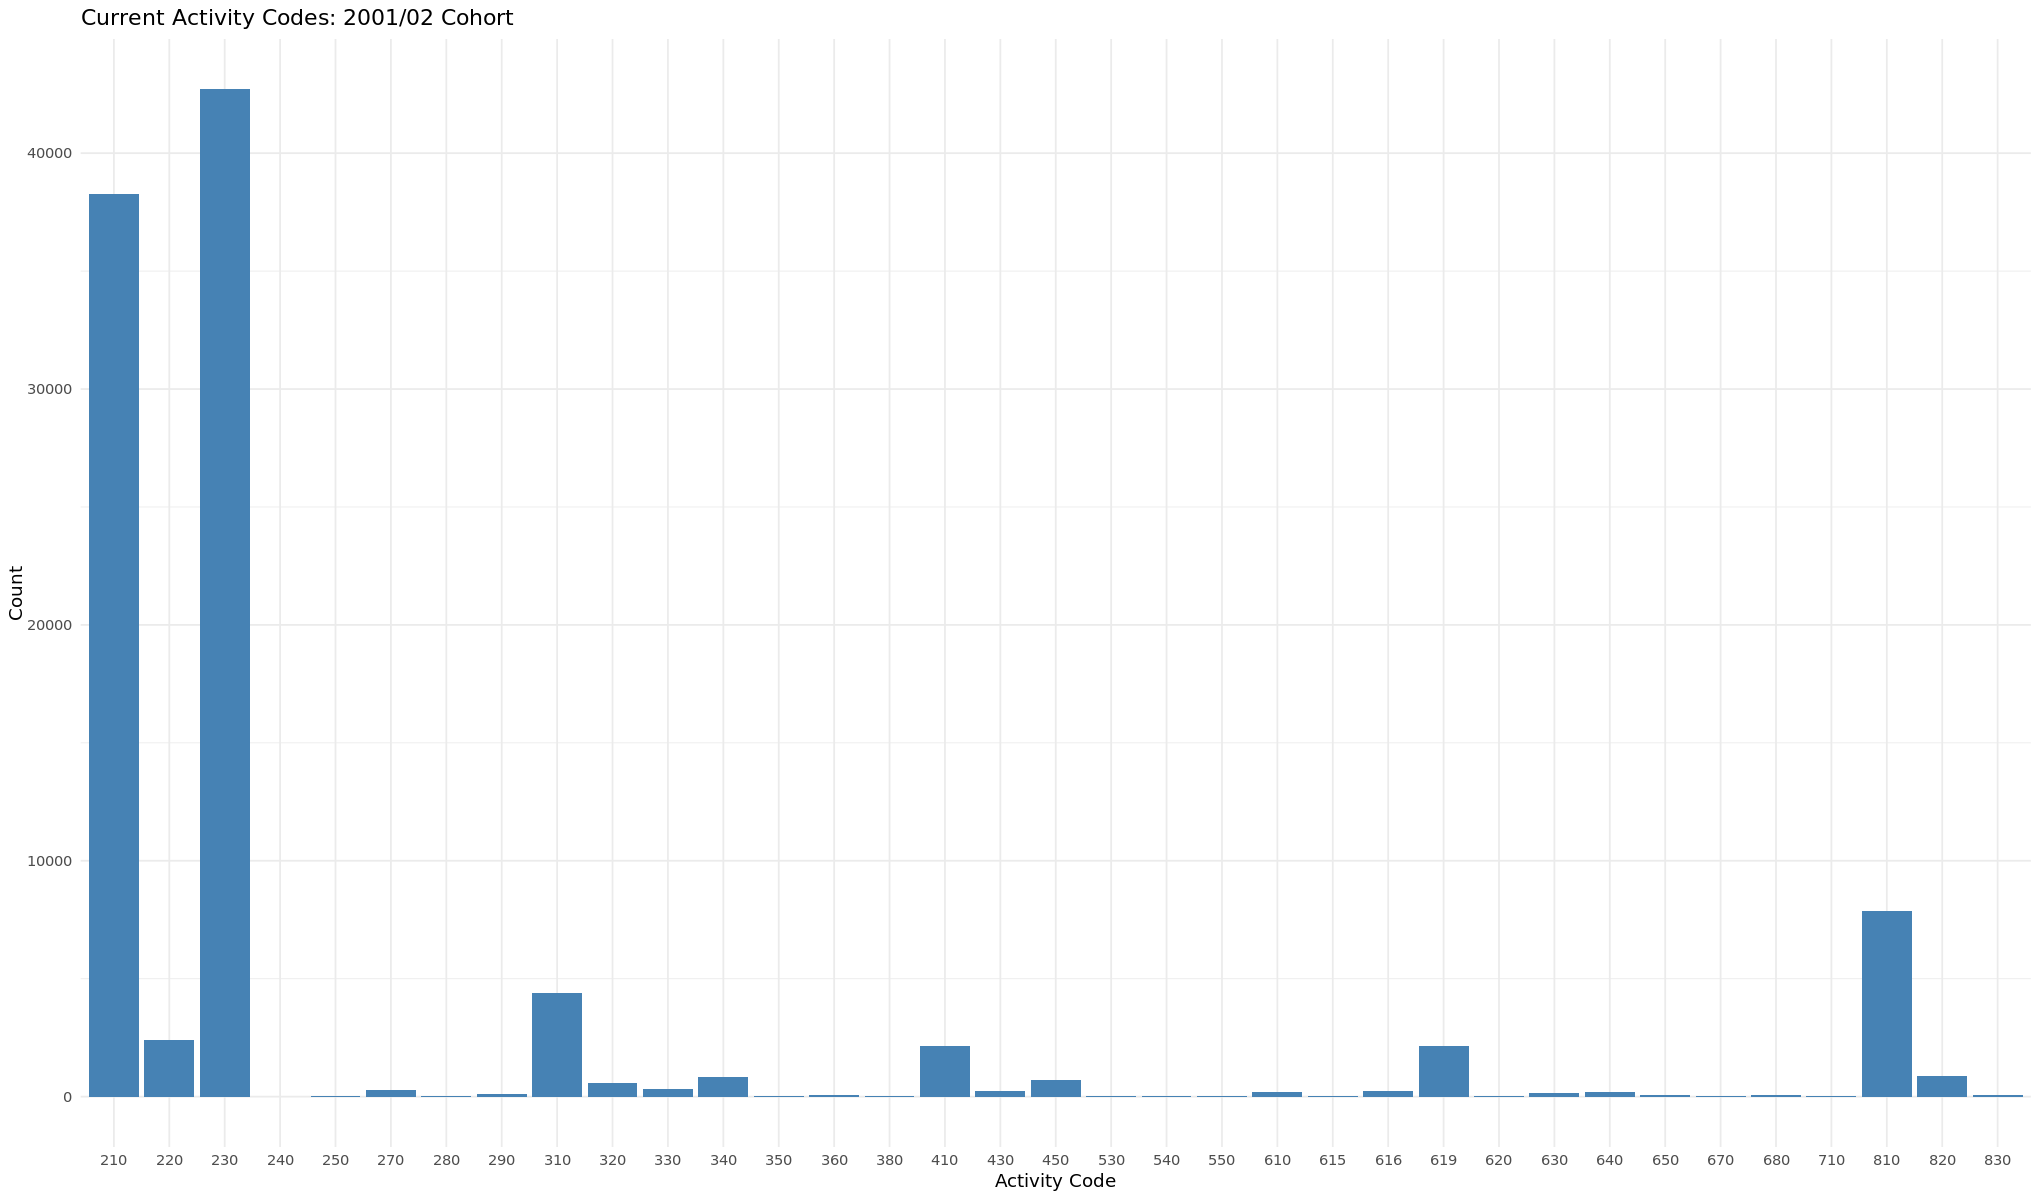

In [76]:
options(repr.plot.width = 17, repr.plot.height = 10)

destinations_filtered %>%
  filter(cohort == '2001/02') %>%
  ggplot(aes(x = NCCIS_Current_Activity_Code)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Current Activity Codes: 2001/02 Cohort", x = "Activity Code", y = "Count") +
  theme_minimal()

In [77]:
NEET_activity <- destinations_filtered |>
    filter(NCCIS_Current_Activity_Code %in% c('540','610','615','616','619','620','630','640','650','660','670','680','710','810','820','830'))

# ,'710','810','820','830'

In [78]:
NEET_activity  |>
 group_by(cohort) |>
 tally()

cohort,n
<chr>,<int>
2000/01,10959
2001/02,11909


In [79]:
NEET_activity |> 
  group_by(cohort) |>
  summarise(num_unique = n_distinct(person_id))

cohort,num_unique
<chr>,<int>
2000/01,5395
2001/02,5275


In [80]:
NEET_activity |> 
  filter(person_id == '40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,4,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,8,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,3,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,6,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,5,NA,619,2019-02-25,2019-02-25,380,2001/02
40C31E0E3726704907E720948AF22D6565BE912A5DCFAE5A4D54C123A423BD5A,2018/2019,7,NA,619,2019-02-25,2019-02-25,380,2001/02


In [81]:
NEET_activity_1718 <- NEET_activity |>
    filter(NCCIS_ACADYR == '2017/2018')

In [82]:
NEET_activity_1718 |> 
    group_by(NCCIS_Current_Activity_Code) |>
    summarise(num_unique = n_distinct(person_id))

NCCIS_Current_Activity_Code,num_unique
<chr>,<int>
540,2
610,45
615,9
616,97
619,524
620,3
630,22
640,27
650,17


In [83]:
NEET_activity_1718 |> 
  group_by(NCCIS_Current_Activity_Code) |>
    tally()

NCCIS_Current_Activity_Code,n
<chr>,<int>
540,7
610,148
615,11
616,160
619,1654
620,13
630,125
640,166
650,69


In [84]:
NEET_activity_1819 <- NEET_activity |>
    filter(NCCIS_ACADYR == '2018/2019')

In [85]:
NEET_activity_1819 |> 
    group_by(NCCIS_Current_Activity_Code) |>
    summarise(num_unique = n_distinct(person_id))

NCCIS_Current_Activity_Code,num_unique
<chr>,<int>
540,2
610,62
615,4
616,119
619,680
620,6
630,27
640,35
650,16


In [86]:
NEET_activity_1819 |> 
  group_by(NCCIS_Current_Activity_Code) |>
    tally()

NCCIS_Current_Activity_Code,n
<chr>,<int>
540,13
610,184
615,7
616,252
619,2136
620,28
630,148
640,184
650,71


In [87]:
NEET_activity |> 
  filter(person_id == '6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,6,NA,830,2019-06-28,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,8,NA,830,2019-06-28,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,2,NA,619,2019-02-26,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,12,NA,640,2018-12-06,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,7,NA,830,2019-06-28,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,3,NA,619,2019-02-26,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,9,NA,810,2018-08-14,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,4,NA,619,2019-02-26,2018-12-06,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,10,NA,810,2018-08-14,NA,380,2001/02


In [88]:
NEET_activity |> 
  filter(NCCIS_Current_Activity_Code == 830)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Year_11_Intended_Destination,NCCIS_Current_Activity_Code,NCCIS_Current_Activity_Start_Date,NCCIS_NEET_Start_Date,NCCIS_Lead_LEA_Code,cohort
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
BBC138EF2E1648D6FE2DC033157F1A931F4241CEDF3AE20AD788C5D0BA2063DD,2018/2019,3,NA,830,2019-03-28,NA,380,2001/02
6A484E7E45ECA7A7722DB9289200E93EA4445A6FD11E219F5C2FE0222184F0B2,2017/2018,7,NA,830,2018-01-30,NA,380,2000/01
777D714DF89FD429075F60E0F8EDB810CC49467AD3891259D90F8AB68AB17365,2017/2018,1,NA,830,2018-01-29,NA,380,2000/01
FA9F2C8A1CD0DB3577DEC062D5CF7989684A288E27196F6C96DE787B4F922A8C,2018/2019,3,NA,830,2019-02-27,NA,380,2001/02
6B720C4F05F1A0DB90A73A75ADE360AB26D11EA77ACBA3657F98CC3769F427AC,2018/2019,6,NA,830,2019-06-28,NA,380,2001/02
F3F0A4C2D125E42E7D9B1FE9743420F78E9EB8045B0C70E5D475EA5A72C3A71C,2017/2018,12,NA,830,2017-08-15,NA,380,2000/01
BDB321813E70EF2CEFAD84FDE8CC710E98E192F585AFDC7F8D85CD9819579E0F,2018/2019,4,NA,830,2019-03-11,NA,380,2001/02
6740A6FB3BCDEFA29131F12EF3B56528BA10E66CB5BE80164203B62F52778E55,2018/2019,6,NA,830,2018-10-22,NA,380,2001/02
EE7845EC75B224F12468CE881715440AC1910374E35002803A04E7FBEA4274D8,2018/2019,5,NA,830,2018-10-31,NA,381,2001/02


## Tidy destinations and activity

In [25]:
destinations_clean <- destinations_filtered

In [26]:
destinations_clean <- destinations_clean |>
    mutate(Current_activity = 
           case_when(
               NCCIS_Current_Activity_Code %in% c('210','220','230','240','250','260','270','280','290') ~ 'Education',
               NCCIS_Current_Activity_Code %in% c('310','320','330','340','350','360','380','381','550') ~ 'Employment',
               NCCIS_Current_Activity_Code %in% c('410','430','440','450','460') ~ 'Training',
               NCCIS_Current_Activity_Code %in% c('530','540','610','615','616','619','620','630','640','650','660','670','680','710') ~ 'NEET',
               NCCIS_Current_Activity_Code %in% c('810','820') ~ NA,
               NCCIS_Current_Activity_Code == '830' ~ 'Refused',
               TRUE ~ NA
               )
           )
               

In [27]:
destinations_clean |>
    group_by(Current_activity) |>
    tally()

Current_activity,n
<chr>,<int>
Education,155840
Employment,11210
NEET,5280
Refused,175
Training,4343
NA,16448


In [28]:
destinations_clean <- destinations_clean |>
    mutate(NEET_detail = 
           case_when(
               NCCIS_Current_Activity_Code == '530' ~ 'Re-engagement',
               NCCIS_Current_Activity_Code == '540' ~ 'Working: no reward',
               NCCIS_Current_Activity_Code == '610' ~ 'Not ready',
               NCCIS_Current_Activity_Code == '615' ~ 'Start date agreed',
               NCCIS_Current_Activity_Code == '616' ~ 'Start date agreed',
               NCCIS_Current_Activity_Code == '619' ~ 'Seeking EET',
               NCCIS_Current_Activity_Code == '620' ~ 'Carer',
               NCCIS_Current_Activity_Code == '630' ~ 'Teen parent',
               NCCIS_Current_Activity_Code == '640' ~ 'Illness',
               NCCIS_Current_Activity_Code == '650' ~ 'Pregnancy',
               NCCIS_Current_Activity_Code == '660' ~ 'Religious grounds',
               NCCIS_Current_Activity_Code == '670' ~ 'Economically inactive',
               NCCIS_Current_Activity_Code == '680' ~ 'Other',
               NCCIS_Current_Activity_Code == '710' ~ 'Custody',
               TRUE ~ NA
               )
           )

In [29]:
destinations_clean |>
    group_by(NEET_detail) |>
    tally()

NEET_detail,n
<chr>,<int>
Carer,40
Custody,15
Economically inactive,36
Illness,301
Not ready,256
Other,137
Pregnancy,215
Re-engagement,86
Seeking EET,3377


In [30]:
head(destinations_clean)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,NCCIS_Current_Activity_Code,cohort,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
42274E959CD577FFC08AF6C01D2E584755BE6176D7AAAB2852CEB554DA72C694,2015/2016,9,650,1998/99,NEET,Pregnancy
F1BE95953E6974F219D6F3E7236FDF8572F5710436AE4DBD689FB7FA448B08E1,2015/2016,9,310,1998/99,Employment,NA
F85EF3297BE0264C33692EF3A12E8D3588AD91AF392E3AC8AC66DA88A21C248D,2015/2016,9,616,1998/99,NEET,Start date agreed
093F44F9B644EAF860C57CD47E3E8720B68C19D6C1AF8F0D28D321116E25423F,2015/2016,9,810,1998/99,NA,NA
4E073ACBD04491273DA9DBF28F9BA45BD228579F64960D9ACAD809CFAC129C82,2015/2016,9,810,1998/99,NA,NA
0893D24C1FBCE03BBD33127781149AB6B90EFF9363E816DD03F7F8257C735BFA,2015/2016,9,320,1998/99,Employment,NA


In [31]:
destinations_clean <- destinations_clean |>
    select(-c(NCCIS_Current_Activity_Code, cohort))

In [32]:
head(destinations_clean)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<chr>,<chr>
42274E959CD577FFC08AF6C01D2E584755BE6176D7AAAB2852CEB554DA72C694,2015/2016,9,NEET,Pregnancy
F1BE95953E6974F219D6F3E7236FDF8572F5710436AE4DBD689FB7FA448B08E1,2015/2016,9,Employment,NA
F85EF3297BE0264C33692EF3A12E8D3588AD91AF392E3AC8AC66DA88A21C248D,2015/2016,9,NEET,Start date agreed
093F44F9B644EAF860C57CD47E3E8720B68C19D6C1AF8F0D28D321116E25423F,2015/2016,9,NA,NA
4E073ACBD04491273DA9DBF28F9BA45BD228579F64960D9ACAD809CFAC129C82,2015/2016,9,NA,NA
0893D24C1FBCE03BBD33127781149AB6B90EFF9363E816DD03F7F8257C735BFA,2015/2016,9,Employment,NA


## Destinations single record

In [33]:
destinations_clean |>
  group_by(person_id, NCCIS_MonthNo) |> 
  filter(n() > 1) |> 
  summarise(count = n(), .groups = "drop") |> 
  summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
329


In [36]:
destinations_clean <- destinations_clean |>
  arrange(person_id, NCCIS_MonthNo, Current_activity) |>
    distinct()

In [37]:
destinations_clean |>
  group_by(person_id, NCCIS_MonthNo) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<chr>,<chr>
01D4C5437E5A02C67E1473FEF63139486A1A85EA656181F6B68633068E174AEB,2015/2016,11,Education,NA
01D4C5437E5A02C67E1473FEF63139486A1A85EA656181F6B68633068E174AEB,2015/2016,11,NEET,Seeking EET
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,9,NEET,Seeking EET
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,9,NA,NA
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,10,NEET,Seeking EET
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,10,NA,NA
02681DD9E411D27F4B0B58E1F0CB8D6D85EED6C7868C8A31E2CFF5CDCD23C55B,2016/2017,8,Education,NA
02681DD9E411D27F4B0B58E1F0CB8D6D85EED6C7868C8A31E2CFF5CDCD23C55B,2016/2017,8,NA,NA
02681DD9E411D27F4B0B58E1F0CB8D6D85EED6C7868C8A31E2CFF5CDCD23C55B,2016/2017,9,Education,NA


#### split intended destinations and currect activity before removing 'not known' duplicates

In [29]:
dest_split <- destinations_clean |>
    select(-c(Current_activity, NEET_detail))

In [31]:
dest_split <- dest_split |>
  arrange(person_id)

In [32]:
dest_split |>
  group_by(person_id) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo
<chr>,<chr>,<dbl>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,1
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,2
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,3
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,4
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,5
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,6
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,7
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,8
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,9


In [33]:
# order of priority: EET, NEET, NA
dest_split_clean <- dest_split |>
    group_by(person_id) |> 
    distinct(person_id, .keep_all = TRUE) |>
    select(c(person_id))

In [34]:
dest_split_clean |>
    group_by(person_id) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [35]:
head(dest_split_clean)

person_id
<chr>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909
00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D
00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7


#### Activity split

In [38]:
activ_split <- destinations_clean

In [39]:
# automatic order of priority: Edu, Emp, NEET, Refused, Train, NA
activ_split <- activ_split |>
    mutate(Current_activity = factor(Current_activity, levels = c("Education", "Employment", "Training", "NEET", "Refused", NA ))) |>
    arrange(person_id, NCCIS_MonthNo, Current_activity) |>
    distinct()

In [40]:
activ_split |>
  group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>
01D4C5437E5A02C67E1473FEF63139486A1A85EA656181F6B68633068E174AEB,2015/2016,11,Education,NA
01D4C5437E5A02C67E1473FEF63139486A1A85EA656181F6B68633068E174AEB,2015/2016,11,NEET,Seeking EET
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,9,NEET,Seeking EET
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,9,NA,NA
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,10,NEET,Seeking EET
02340F3F5D13AB36293E7F6DF375CE9AAE460153C9B2F3682ABF23C881A11830,2016/2017,10,NA,NA
02681DD9E411D27F4B0B58E1F0CB8D6D85EED6C7868C8A31E2CFF5CDCD23C55B,2016/2017,8,Education,NA
02681DD9E411D27F4B0B58E1F0CB8D6D85EED6C7868C8A31E2CFF5CDCD23C55B,2016/2017,8,NA,NA
02681DD9E411D27F4B0B58E1F0CB8D6D85EED6C7868C8A31E2CFF5CDCD23C55B,2016/2017,9,Education,NA


In [44]:
# manual order of priority
activ_split_clean <- activ_split |>
    distinct(person_id, NCCIS_MonthNo, .keep_all = TRUE)
    

In [46]:
activ_split_clean |>
  group_by(person_id, NCCIS_MonthNo) |> 
  filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>


In [47]:
activ_split_clean |>
    group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [48]:
activ_split_clean

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,1,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,2,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,3,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,4,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,5,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,6,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,7,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,8,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,9,NA,NA


#### Re-join and pivot wide

In [49]:
dest_joined <- activ_split_clean

In [50]:
dest_joined |>
    group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [51]:
dest_joined |>
    group_by(person_id, NCCIS_MonthNo) |> 
      filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>


In [48]:
dest_joined 

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity,NEET_detail
<chr>,<chr>,<dbl>,<fct>,<chr>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,1,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,2,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,3,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,4,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,5,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,6,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,7,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,8,Education,NA
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,9,NA,NA


In [52]:
dest_joined |>
    group_by(Current_activity) |>
    tally()

Current_activity,n
<fct>,<int>
Education,155510
Employment,11097
Training,4302
NEET,5125
Refused,135
NA,15649


In [52]:
destinations_wide <- dest_joined |>
    select(-(NEET_detail)) |>
    pivot_wider(
        names_from = NCCIS_MonthNo,
        values_from = Current_activity,
        values_fill = NA
        ) |>
    select(c(person_id,NCCIS_ACADYR,'9','10','11','12','1','2','3','4','5','6','7','8'))

In [53]:
head(destinations_wide)

person_id,NCCIS_ACADYR,9,10,11,12,1,2,3,4,5,6,7,8
<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
00063B7DE8D61E07E54571351684A37504385EBD55879708236F3579C4E33661,2015/2016,Education,Education,Education,NA,NA,Employment,Employment,NA,Employment,Employment,Employment,Employment
000709767CB306493FC46DAC5E2E6B92D691A0C8A5299139ACA3871DAE72A909,2015/2016,NA,Education,Education,Education,NA,Education,Education,NA,Education,Education,NA,NA
00131B1E9F8FD120B0E688913FCFE2F0C27F1B2C6584AE0378B38B75E74B10AC,2016/2017,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,Education,Education,Education,Education,Education,Education,NEET,NEET,NEET,NEET,NEET,NEET
00183D5045A271DEF4B6CC51797F891551229B01E913B4C0619CCBC638EA63E7,2016/2017,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA


In [120]:
# Save as CSV

In [54]:
write.csv(destinations_wide, "data/additional_destinations_wide.csv", row.names = FALSE)

In [63]:
dest_joined_detail <- dest_joined |>
    mutate(Current_activity = case_when(
        Current_activity == "NEET" & !is.na(NEET_detail) ~ paste0("NEET: ", NEET_detail),
        TRUE ~ Current_activity
  )) |>
    select(-NEET_detail)

In [64]:
dest_joined_detail |>
    group_by(person_id, NCCIS_ACADYR, NCCIS_MonthNo) |> 
      filter(n() > 1) |> 
      summarise(count = n(), .groups = "drop") |> 
      summarise(num_persons_with_duplicates = n_distinct(person_id))

num_persons_with_duplicates
<int>
0


In [65]:
dest_joined_detail |>
    group_by(person_id, NCCIS_MonthNo) |> 
      filter(n() > 1)

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity
<chr>,<chr>,<dbl>,<chr>


In [66]:
dest_joined_detail

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity
<chr>,<chr>,<dbl>,<chr>
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,1,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,2,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,3,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,4,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,5,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,6,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,7,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,8,Education
0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,9,NA


In [67]:
dest_joined_detail |>
    filter(person_id == '0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D')

person_id,NCCIS_ACADYR,NCCIS_MonthNo,Current_activity
<chr>,<chr>,<dbl>,<chr>
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,1,Education
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,2,Education
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,3,NEET: Start date agreed
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,4,NEET: Start date agreed
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,5,NEET: Start date agreed
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,6,NEET: Start date agreed
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,7,NEET: Start date agreed
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,8,NEET: Start date agreed
0015AFB059DFAA539E96CA31373F8B3E2244BBE7737F72CD606C785A47AA862D,2016/2017,9,Education


In [68]:
destinations_wide_detail <- dest_joined_detail |>
    pivot_wider(
        names_from = NCCIS_MonthNo,
        values_from = Current_activity,
        values_fill = NA
        ) |>
    select(c(person_id,NCCIS_ACADYR,'9','10','11','12','1','2','3','4','5','6','7','8'))

In [69]:
destinations_wide_detail |>
    group_by(person_id) |>
    filter(n() > 1)

person_id,NCCIS_ACADYR,9,10,11,12,1,2,3,4,5,6,7,8
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>


#### save destinations with NEET detail as csv 

In [70]:
write.csv(destinations_wide_detail, "data/additional_destinations_wide_detail.csv", row.names = FALSE)

In [129]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Education")) |>
    nrow()

[1] 6080

In [130]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Employment")) |>
    nrow()

[1] 290

In [131]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Training")) |>
    nrow()

[1] 37

In [132]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ . == "Refused")) |>
    nrow()

[1] 1

In [133]:
destinations_wide_detail |>
    filter(if_all(`9`:`8`, is.na)) |>
    nrow()

[1] 182

In [134]:
# records with ALL neet status
destinations_wide_detail |>
    filter(if_all(`9`:`8`, ~ str_starts(., "NEET"))) |>
    nrow()

[1] 29

In [135]:
# records with ANY neet status
destinations_wide_detail |>
    filter(if_any(`9`:`8`, ~ str_starts(., "NEET"))) |>
    nrow()

[1] 1390

In [136]:
destinations_wide_detail <- destinations_wide_detail |>
    rowwise() |>
    mutate(neet_count = sum(str_starts(c_across(`9`:`8`), "NEET"), na.rm = TRUE))

In [138]:
# records with majority neet status
destinations_wide_detail |>
    filter(neet_count >= 9) 

person_id,NCCIS_ACADYR,Intended_destination,9,10,11,12,1,2,3,4,5,6,7,8,neet_count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
00D2D54BE54AA2D95A4868BF01E6147645BD35B1DE9161DC1AC32D1B2570E2E7,2017/2018,NA,NEET: Seeking EET,Employment,Employment,Employment,NEET: Seeking EET,NEET: Seeking EET,NEET: Pregnancy,NEET: Pregnancy,NEET: Pregnancy,NEET: Teen parent,NEET: Teen parent,NEET: Teen parent,9
02595CE994DD5ECD2F333CA5DBBD7B837CBF7D7DA266D568C3E685E6548AE7C4,2018/2019,NA,Education,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,11
03775A2E25D4145883BF71B42DA0A6E54F6ACECB0D883B47F5E145FC8645D83B,2017/2018,NA,NA,NA,NA,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,9
0BA571FAB8736DC2F5593C7CF04A1E755E046E4A8872FB4FD224C7049107C7BE,2017/2018,NA,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,Refused,Refused,Refused,9
0C824E388720F4BE7B318BE44F24E5B388D46DB77AB71198426BA62C12092F7A,2017/2018,NA,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Not ready,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,12
0DC4FC68F13B38B8DBB02D6366CFC8F62D560F1672638BB3E9CFE93FAC516AC5,2018/2019,NA,NA,NA,NA,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,NEET: Illness,9
162B7DE34DC5E1E98CB7CE1C0987E20DDD3E5E9E1583AD0E440EC6B6D858AE1F,2017/2018,NA,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,NEET: Re-engagement,12
16CCD5CDF042931FE711F9B2D9739455275BD8F40BBBAA5A2F06DAC3BB981D77,2017/2018,NA,NEET: Seeking EET,NEET: Not ready,NEET: Not ready,NEET: Seeking EET,NEET: Seeking EET,NEET: Not ready,Employment,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,NEET: Not ready,NEET: Start date agreed,11
176CF1A5DFEA7AA131EBA908B307E884FBF560F87E2200C6D868623FD38CA3FF,2017/2018,NA,NA,NA,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,NEET: Other,10
